In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import anndata as an
from kneed import KneeLocator

### 1. Select the guides for analysis

/tmp/ipykernel_551350/3016108683.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df.index, df['IntersectionCount'],


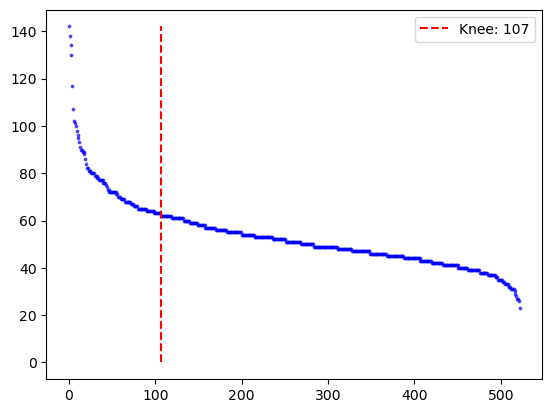

In [4]:

pert_type = "crispra"  # or "crispri"

df = pd.read_csv(f'/home/user/Documents/Kinase_project/{pert_type}_final/deg_ntc_kinases.csv')
plt.scatter(df.index, df['IntersectionCount'], 
            s=3,  # size of points
            c='blue',  # color of points
            alpha=0.6,  # transparency
            cmap='viridis')  # color map

# Increase S to be more strict (e.g., S=15 or S=20)
kn = KneeLocator(df.index, df['IntersectionCount'], curve='convex', direction='decreasing', S=10)
kn.knee

# Plot the knee location
plt.vlines(kn.knee, ymin=0, ymax=df['IntersectionCount'].max(), linestyles='dashed', colors='red', label=f'Knee: {kn.knee}')
plt.legend()
plt.show()

top_kinases = df['Kinase'].head(kn.knee).values
valid_gene_ids = list(top_kinases) + ['NTC']


In [5]:
top_kinases

array(['PRKG1', 'RPS6KB1', 'CSNK1G3', 'BUB1B', 'RYK', 'RPS6KA4', 'PAK7',
       'MAPKAPK2', 'FES', 'FGFR4', 'HIPK3', 'CSK', 'AATK', 'IRAK4',
       'MAPK7', 'SCYL1', 'PSKH1', 'MUSK', 'STRADB', 'EPHA5', 'TLK2',
       'PIM3', 'MAP3K19', 'CLK1', 'STRADA', 'MAPK1', 'ERBB4', 'BMP2K',
       'TRIB3', 'CDK5', 'HSPB8', 'PDGFRB', 'EIF2AK1', 'CAMK2G', 'KIT',
       'MAST2', 'MAP3K5', 'STYK1', 'TYRO3', 'BCKDK', 'FYN', 'CDK6',
       'ALPK3', 'MKNK1', 'RPS6KA6', 'GRK6', 'NEK11', 'MAST1', 'GSK3A',
       'CDK10', 'PIM1', 'CDK3', 'JAK1', 'EPHB3', 'ULK3', 'HCK', 'PRPF4B',
       'random', 'PEAK1', 'EPHB6', 'NTRK2', 'CSNK1D', 'MAP2K2', 'CAMKK2',
       'GRK4', 'TNNI3K', 'ADCK3', 'PDK1', 'ALPK2', 'ACVR1C', 'PLK4',
       'BRAF', 'PAK2', 'KDR', 'MAPK12', 'FER', 'PHKG2', 'LMTK2', 'BMPR2',
       'DYRK2', 'LRRK1', 'CDKL4', 'ACVR1B', 'MAP4K3', 'LATS2', 'MAK',
       'VRK1', 'BTK', 'STK19', 'SPEG', 'GRK5', 'PDK4', 'TESK1', 'CASK',
       'KIAA1804', 'DYRK4', 'PAK4', 'TSSK6', 'MAP3K3', 'TNK2', 'OXSR1',
    

### 2. Prepare TCDG files

In [6]:
df = pd.read_csv(f'/home/user/Documents/Kinase_project/figures/decipher_analysis/NTC_{pert_type}/T_cell_dose_gene.csv')
T_cell_dose_gene = df['gene_short_name']

In [7]:
T_cell_dose_gene

0           TSPAN6
1              CFH
2             GCLC
3           NIPAL3
4            ENPP4
           ...    
3953    AC104662.2
3954          CDR1
3955    AC116366.3
3956    AC004922.1
3957    AC119674.2
Name: gene_short_name, Length: 3958, dtype: object

### 3. Generate raw and hvg files

In [9]:
gbm= an.read_h5ad(f'/home/user/Documents/Kinase_project/{pert_type}_final/preprocessed_cds_without_Tcells.h5ad')

In [10]:
gbm

AnnData object with n_obs × n_vars = 317405 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [11]:
# Filter out cells where sgRNA is NA
gbm = gbm[~gbm.obs['sgRNA'].isna()].copy()
gbm

AnnData object with n_obs × n_vars = 317405 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [12]:
gbm.X.max()

4161.0

In [13]:
gbm_crop = gbm[
    (gbm.obs['total_sgrna_read_per_cell'] > 3) & 
    (gbm.obs['top_proportion'] > 0.3)
].copy()
gbm_crop

AnnData object with n_obs × n_vars = 258817 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [14]:
filtered_gbm_crop = gbm_crop[gbm_crop.obs['gene_id'].isin(valid_gene_ids)]
print("Filtered gene IDs:", filtered_gbm_crop.obs['gene_id'].unique())

Filtered gene IDs: ['NTRK2' 'NTC' 'random' 'FYN' 'CDK6' 'TNK2' 'LRRK1' 'MKNK1' 'TLK2' 'GRK6'
 'GRK5' 'GSK3A' 'TNNI3K' 'HSPB8' 'MAST1' 'ACVR1B' 'CDK10' 'MAP4K3' 'PIM1'
 'PDGFRB' 'PSKH1' 'CSNK1D' 'PEAK1' 'AATK' 'LATS2' 'ERBB4' 'PAK2' 'KDR'
 'PDK1' 'PIM3' 'MAPK7' 'FLT1' 'MAST2' 'HIPK3' 'PRKG1' 'CLK1' 'AAK1'
 'IRAK4' 'HCK' 'MAP3K5' 'MAP3K19' 'OXSR1' 'ALPK3' 'MAK' 'BMP2K' 'ADCK3'
 'FGFR4' 'TESK1' 'STRADA' 'LMTK2' 'BMPR2' 'CASK' 'EPHA5' 'TRIB3'
 'KIAA1804' 'ACVR1C' 'CSNK1G3' 'CDK3' 'FER' 'MAPK1' 'RPS6KB1' 'EIF2AK1'
 'DYRK4' 'VRK1' 'EPHB6' 'CDKL4' 'BUB1B' 'JAK1' 'DYRK2' 'MAPK12' 'PLK4'
 'KIT' 'STYK1' 'MAP2K2' 'CAMK1D' 'EPHB3' 'RPS6KA4' 'PAK4' 'NEK11'
 'RPS6KA6' 'ALPK2' 'BRAF' 'TYRO3' 'CSK' 'MAPKAPK2' 'PDK2' 'PAK7' 'RYK'
 'BCKDK' 'FES' 'CAMKK2' 'PHKG2' 'RIPK2' 'CAMK4' 'STK19' 'ULK3' 'SPEG'
 'STRADB' 'CAMK2G' 'CDK5' 'MUSK' 'TSSK6' 'SCYL1' 'MAP3K3' 'GRK4' 'BTK'
 'PDK4' 'PRPF4B']


In [15]:
gene_id_counts = filtered_gbm_crop.obs['gene_id'].value_counts()
gene_id_counts

gene_id
NTC       24991
random     1150
FER        1087
TNK2        954
MKNK1       905
          ...  
EPHA5       242
BUB1B       236
MAP4K3      229
BMP2K       223
BRAF        209
Name: count, Length: 108, dtype: int64

In [16]:
# Filter genes with >= 25 cells
valid_gene_ids = gene_id_counts[gene_id_counts >= 25].index
filtered_gbm_crop = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'].isin(valid_gene_ids)]
filtered_gene_id_counts = filtered_gbm_crop.obs['gene_id'].value_counts()
filtered_gene_id_counts

gene_id
NTC       24991
random     1150
FER        1087
TNK2        954
MKNK1       905
          ...  
EPHA5       242
BUB1B       236
MAP4K3      229
BMP2K       223
BRAF        209
Name: count, Length: 108, dtype: int64

In [17]:
filtered_gbm_crop.obs['gene_id']

01A_A01_RT_BC_100_Lig_BC_103     NTRK2
01A_A01_RT_BC_100_Lig_BC_138       NTC
01A_A01_RT_BC_100_Lig_BC_140    random
01A_A01_RT_BC_100_Lig_BC_146       FYN
01A_A01_RT_BC_100_Lig_BC_192       NTC
                                 ...  
12A_H12_RT_BC_99_Lig_BC_27         NTC
12A_H12_RT_BC_99_Lig_BC_5       random
12A_H12_RT_BC_99_Lig_BC_91       TESK1
12A_H12_RT_BC_99_Lig_BC_94         NTC
12A_H12_RT_BC_99_Lig_BC_98       MAST2
Name: gene_id, Length: 71799, dtype: object

In [18]:
# Filter NTC cells
ntc_cells = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] == 'NTC']

# Randomly sample 489 NTC cells (Top kinases gene count)
ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=1).index
ntc_sampled_adata = filtered_gbm_crop[filtered_gbm_crop.obs.index.isin(ntc_sampled_indices)].copy()

# Filter out NTC cells from the original data to get non-NTC data
non_ntc_adata = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] != 'NTC']

# Combine sampled NTC cells with non-NTC data
combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)
combined_adata

/tmp/ipykernel_551350/976759071.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=1).index
/tmp/ipykernel_551350/976759071.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)


AnnData object with n_obs × n_vars = 47958 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster', 'batch'
    var: 'features'

In [19]:
combined_adata.obs['gene_id'].value_counts()

gene_id
NTC       1150
random    1150
FER       1087
TNK2       954
MKNK1      905
          ... 
EPHA5      242
BUB1B      236
MAP4K3     229
BMP2K      223
BRAF       209
Name: count, Length: 108, dtype: int64

In [20]:
combined_adata_tcdg = combined_adata[:, combined_adata.var['features'].isin(T_cell_dose_gene.values)]
combined_adata_tcdg

View of AnnData object with n_obs × n_vars = 47958 × 3958
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster', 'batch'
    var: 'features'

In [21]:
combined_adata_tcdg.var.rename(columns={'_index':'index'},inplace=True)
combined_adata_tcdg.raw.var.rename(columns={'_index':'index'},inplace=True) 
combined_adata_tcdg.write_h5ad(f'/home/user/Documents/Kinase_project/{pert_type}_final/filtered_gbm_{pert_type}_crop.h5ad')

/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/user/anaconda3